In [4]:
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated
import faiss

from langchain_community.vectorstores import FAISS
import warnings
warnings.filterwarnings('ignore')


# Prepare vector Store and Sentence embedding


In [5]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("data/attentation-all-you-need.pdf")
docs = loader.load()
len(docs)

15

In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 80
)

documents = splitter.split_documents(documents=docs)
len(documents)

96

In [7]:
documents[2]

Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'data/attentation-all-you-need.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='mechanism. We propose a new simple network architecture, the Transformer,\nbased solely on attention mechanisms, dispensing with recurrence and convolutions\nentirely. Experiments on two machine translation tasks show these models to\nbe superior in quality while being more parallelizable and requiring significantly\nless time to train. Our model achieves 28.4 BLEU on the WMT 2014 English-\nto-German translation task, improving over the existing best results, including')

In [8]:
from dotenv import load_dotenv
import os
load_dotenv()
from langchain_groq import ChatGroq

os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")

In [9]:
len(embeddings.embed_query("hello"))


768

In [10]:
index = faiss.IndexFlatIP(768)


In [11]:
from langchain_community.docstore.in_memory import InMemoryDocstore


In [12]:
vector_store = FAISS(
 embedding_function=embeddings,
 index=index,
 docstore=InMemoryDocstore(),
 index_to_docstore_id={}
)


In [13]:
vector_store.add_documents(documents=documents)


['2292aabf-a3f3-4e91-84cd-87934cf11e2f',
 'b6f60d99-2a24-439f-ad7c-4e8d1a3db9c4',
 '81c5bbca-76df-4985-8c89-a4088ece9195',
 '212cfe2a-b26e-40a2-bc59-705bfb37f13b',
 '533f1270-3cf6-48c9-953f-9e91e80a33fa',
 'bdcf8d0d-acc7-4a1e-820f-a0743fe88b99',
 '59af0641-cdb6-4923-ba44-98c779595866',
 'c4c11556-b0d2-4948-a449-26fa8ed1e497',
 'b1d8004e-e4dd-4cff-bd6f-7a2f801cc53f',
 '4de39ab1-38cf-4537-b167-b7196a18ba48',
 '9e302db7-419a-4923-88a3-afa3faa6b09c',
 '77405d44-0445-4d30-8bf4-d8ffc383a676',
 '7670a6d6-aebb-4559-896b-0a24956169a3',
 '75aec289-34b4-4a90-b64e-152f42721a77',
 '9b72a34c-8084-4166-a0a0-5a278599ef44',
 '37cb979c-f692-4b8a-a3b7-dc3c04b79c79',
 '008b1a33-75b0-444d-a220-0f27dd51bdab',
 'ab795368-dc00-40b4-84f7-1dda0edfccdf',
 'e42e4416-043f-41dc-a231-610112276e5d',
 'b518c0ed-ec84-4196-ad70-bf9c91dfe8b2',
 '359211f1-ac07-4fca-a338-8c8d851d565d',
 '52bbc3b1-04ae-4492-babf-4682e26d7e2b',
 'cadc28f0-1e51-4a09-b48b-0121ebfed062',
 '9ee8ab1a-5188-4d8f-abb4-bcd5e9368520',
 '151f42dd-cc6f-

In [14]:
vector_store.similarity_search(query="What is autoregressive?")


[Document(id='7b9d545c-6cc4-4f97-af23-1518a7f70009', metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'data/attentation-all-you-need.pdf', 'total_pages': 15, 'page': 5, 'page_label': '6'}, page_content='the maximum path length between any two input and output positions in networks composed of the\ndifferent layer types.\nAs noted in Table 1, a self-attention layer connects all positions with a constant number of sequentially\nexecuted operations, whereas a recurrent layer requires O(n) sequential operations. In terms of\ncomputational complexity, self-attention layers are faster than recurrent layers when the sequence\n6'),
 Document(id='8909ae67-608c-417e-8857-9e7e57394168', metadat

In [17]:
retriever = vector_store.as_retriever(
    search_type = "similarity",
    search_kwargs={
        "k": 3
    }
)

In [18]:
retriever.invoke("What is autoregressive?")


[Document(id='7b9d545c-6cc4-4f97-af23-1518a7f70009', metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'data/attentation-all-you-need.pdf', 'total_pages': 15, 'page': 5, 'page_label': '6'}, page_content='the maximum path length between any two input and output positions in networks composed of the\ndifferent layer types.\nAs noted in Table 1, a self-attention layer connects all positions with a constant number of sequentially\nexecuted operations, whereas a recurrent layer requires O(n) sequential operations. In terms of\ncomputational complexity, self-attention layers are faster than recurrent layers when the sequence\n6'),
 Document(id='8909ae67-608c-417e-8857-9e7e57394168', metadat

In [15]:
from langchain_core.output_parsers import StrOutputParser
from langchain import hub

prompt = hub.pull("rlm/rag-prompt")
prompt.messages[0]

HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})

In [16]:
from langchain_core.runnables import RunnablePassthrough

def format_docs(retriever_docs):
    context_text = "\n\n".join(doc.page_content for doc in retriever_docs)
    return context_text

In [19]:
rag_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough()
    }
    | prompt
    | llm
    | StrOutputParser()
)

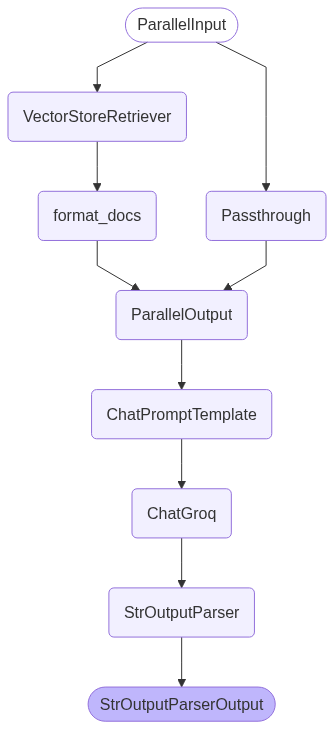

In [20]:
from IPython.display import display, Image
display(Image(rag_chain.get_graph().draw_mermaid_png()))


# Time to build Workstation


In [21]:
from typing import Literal


In [22]:
class SelectPath(BaseModel):
    path: Annotated[Literal["LLM_CALL", "RAG_CALL", "INTERNET_SEARCH"], Field(description="Based on the user query select one path only. if user want to know about the Attention all you need paper or any query related to the Transformer then select the Rag call. if user want to know basics question the select llm call and finally user want to know about recent info then select the internet search.")]
    reason: Annotated[str, Field(description="Why you select a specific path give reason in one sentence.")]


In [23]:
from langchain_core.output_parsers import PydanticOutputParser

parser = PydanticOutputParser(pydantic_object=SelectPath)

In [24]:
path_prompt = PromptTemplate(
    template="""
    Think step by step on user query. The user query: {question}\n\n My vector store is related of Transformer paper as the paper name is *attention all you need* so if you think like user query is related to this paper then select the 'RAG_CALL'. Or user want to know about the latest news or any info the you select the 'INTERNET_SEARCH'. Finally if user want to know basics question such as wants know ML, DL, NLP, or any basics question if you think llm model can capable to give sold and correct answer then select the 'LLM_CALL'. you have to follow this format instruction.\n\n{format_instruction}.
    """,
    input_variables=["question"],
    partial_variables={
        "format_instruction": parser.get_format_instructions()
    }
)

In [25]:
test_chain = path_prompt | llm | parser


In [27]:
test_chain.invoke("What is positional embeddings?")


SelectPath(path='RAG_CALL', reason="The query about positional embeddings is directly related to the Transformer model and the 'Attention is All You Need' paper.")

In [28]:
test_chain.invoke("What is the weather today in Hyderabad?")


SelectPath(path='INTERNET_SEARCH', reason='The user query seeks current and specific information about the weather in Hyderabad, which requires fetching the latest data from the internet.')

In [29]:
response = test_chain.invoke("Why i need to learn Agentic AI?")
response.path, response.reason


('INTERNET_SEARCH',
 'The user query is about understanding the importance or necessity of learning Agentic AI, which suggests a need for recent information or an overview of the field.')

## SETUP

In [30]:
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

tavily_search = TavilySearch(
    max_results=3,
    topic="general"
)

tavily_search.invoke("Capital of bangladesh")

{'query': 'Capital of bangladesh',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'Bangladesh | History, Capital, Map, Flag, Population, Pronunciation ...',
   'url': 'https://www.britannica.com/place/Bangladesh',
   'content': 'Bangladesh is a country of South Asia, located in the delta of the Padma (Ganges) and Jamuna (Brahmaputra) rivers in the northeastern part of the Indian subcontinent. It is one of the most densely populated countries in the world, and its people are predominantly Muslim. Its capital is Dhaka.',
   'score': 0.8652358,
   'raw_content': None},
  {'title': 'Dhaka - Simple English Wikipedia, the free encyclopedia',
   'url': 'https://simple.wikipedia.org/wiki/Dhaka',
   'content': 'Dhaka is the capital and largest city of Bangladesh, with a population of over 22 million. It has a rich history as a Mughal, British, and Pakistani city, and is home to many universities, landmarks, and industries.',
   'score': 0.8593928,
   'raw_c

### Create Agentic State

In [31]:
from typing import TypedDict, Sequence
from langchain_core.messages import BaseMessage
import operator

class State(TypedDict):
    """This is is my graph state where store all conversations."""
    messages: Annotated[Sequence[BaseMessage], operator.add]

### Start to build the Graph Node


In [ ]:
class SelectPath(BaseModel):
    path: Annotated[Literal["LLM_CALL", "RAG_CALL", "INTERNET_SEARCH"], Field(description="Based on the user query select one path only. if user want to know about the Attention all you need paper or any query related to the Transformer then select the Rag call. if user want to know basics question the select llm call and finally user want to know about recent info then select the internet search.")]
    reason: Annotated[str, Field(description="Why you select a specific path give reason in one sentence.")]

from langchain_core.output_parsers import PydanticOutputParser
parser = PydanticOutputParser(pydantic_object=SelectPath)

In [46]:
path_prompt = PromptTemplate(
    template="""
    Think step by step on user query. The user query: {question}\n\n My vector store is related of Transformer paper as the paper name is *attention all you need* so if you think like user query is related to this paper then select the 'RAG_CALL'. Or user want to know about the latest news or any info the you select the 'INTERNET_SEARCH'. Finally if user want to know basics question such as wants know ML, DL, NLP, or any basics question if you think llm model can capable to give sold and correct answer then select the 'LLM_CALL'. you have to follow this format instruction.\n\n{format_instruction}.
    """,
    input_variables=["question"],
    partial_variables={
        "format_instruction": parser.get_format_instructions()
    }
)

In [32]:
## Supervisor node
def supervisor(state: State):
    """This node is responsible for to select the correct path based on the user query."""
    question = state['messages'][-1]
    print(question)
    chain = path_prompt | llm | parser
    response = chain.invoke(question)
    print(response.path, response.reason)
    
    return {
        "messages": [response.path]
    }

In [33]:
state={'messages': ["What is key and value vector?"]}
supervisor(state)

What is key and value vector?
RAG_CALL The user query about key and value vectors is directly related to the Transformer model and its attention mechanism, as as presented in the 'Attention all you need' paper.


{'messages': ['RAG_CALL']}

In [34]:
def router(state: State):
    print("--Router--")
    last_message = state["messages"][-1]
    print(last_message)
    
    if last_message == "RAG_CALL":
        return "RAG_CALL"
    elif last_message == "LLM_CALL":
        return "LLM_CALL"
    else:
        return "INTERNET_SEARCH"

In [50]:
from langchain_core.output_parsers import StrOutputParser

def llm_call(state: State):
    print("--LLM Call--")
    question = state['messages'][0]
    prompt = PromptTemplate(
        template="""
        You are a helpful ai assistant. Answer the question based on you capability. if you think you do not know about the question do not give the answer just simply say i do not know the proper answer. Though do not give any hypothetical answer or hallucination response or do not predict the answer. If you are confident enough then provide the answer properly.\n
        the user query is: {question}
        """,
        input_variables=["question"]
    )
    chain = prompt | llm | StrOutputParser()
    response = chain.invoke(
        {
            "question": question
        }
    )
    print(response)
    return {
        "messages": [response]
    }

In [51]:
def internet_search(state: State):
    print("--Internet Search--")
    question = state['messages'][0]
    web_search_content = tavily_search.invoke(question)
    prompt = PromptTemplate(
        template="""
        You are a helpful ai assistant who can give answer of the user query based on the web search content. First read the user query and check the web_search_content. If you think web content is not enough for to give the answer of the user query then simply say. No have enough context to give the answer. And below the user query and web_search_content.\n\n
        the user query is: {question}\n\n
        the web_search_content: {web_search_content}\n
        """,
        input_variables=["question", "web_search_content"]
    )
    chain = prompt | llm | StrOutputParser()
    response = chain.invoke(
        {
            "question": question,
            "web_search_content": web_search_content
        }
    )
    return {
        "messages": [response]
    }

In [52]:
from langchain import hub
prompt = hub.pull("rlm/rag-prompt")
prompt

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})])

In [53]:
def rag_call(state: State):
    print("--Rag call--")
    question = state['messages'][0]
    print(question)
    prompt = hub.pull("rlm/rag-prompt")
    
    rag_chain = (
        {
            "context": retriever | format_docs,
            "question": RunnablePassthrough()
        }
        | prompt
        | llm
        | StrOutputParser()
    )
    response = rag_chain.invoke(question)
    print("rag-response", response)
    
    return {
        "messages": [response]
    }
    

In [54]:
class validationOutput(BaseModel):
    validation_response: Annotated[Literal["yes", "no"], Field(description="analysis the user question and the output. If you think the output is correct based on the question then say 'yes' otherwise say 'no' if the answer is not correct based on the user question.")]


In [55]:
validate_parser = PydanticOutputParser(pydantic_object=validationOutput)


In [56]:
def validation_node(state: State):
    print("---validation---")
    question = state['messages'][0]
    answer = state['messages'][-1]
    
    print(question, answer)
    validation_prompt = PromptTemplate(
        template="""Think you are evaluator, your task is validate the output of the user question. Example if the answer is correct based on the user question then simple say 'yes', otherwise say 'no' is the answer is not relevant to the question. Think very carefully to validation time. Below the user question and the answer of the question.
        the user question is : {question}\n\n and the output answer of the question is: {answer}.\n\n Most important is must be follow the output format instruction: {format_instruction}""",
        input_variables=["question", "answer"],
        partial_variables={
            "format_instruction": validate_parser.get_format_instructions()
        }
    )
    
    validation_chain = validation_prompt | llm | validate_parser
    
    result = validation_chain.invoke(
        {
            "question": question,
            "answer": answer
        }
    )
    print(result.validation_response)
    return {
        "messages": [result.validation_response]
    }

In [57]:
class RewriteUserQuestion(BaseModel):
    rewrite_question: Annotated[str, Field(description="Rewrite the user query for better output generation. question should be in one sentence.")]


In [58]:
rewrite_parser = PydanticOutputParser(pydantic_object=RewriteUserQuestion)


In [59]:
def rewrite_query(state: State):
    question = state['messages'][0]
    
    rewrite_prompt = PromptTemplate(
        """You are a helpful ai assistant and your task is rewrite the user input query for better response generation. Example like if user query is bad then occurred problem such as data extraction from vector store or internet search. So rewrite the query for best output generation.\n
        This is user question: {question}. and must be follow the format instruction to produce the output. The format instruction is: {format_instruction}""",
        input_variables=["question"],
        partial_variables={
            "format_instruction": rewrite_parser.get_format_instructions()
        }
    )
    
    rewrite_chain = rewrite_prompt | llm | rewrite_parser
    new_question = rewrite_chain.invoke(
        {
            "question": question
        }
    )
    state["messages"][0] = new_question.rewrite_question
    print(state["messages"][0])
    

In [60]:
from langgraph.graph import END

def validation_router(state: State):
    validation_result = state['messages'][-1]
    
    if validation_result == "yes":
        return "PASS"
    else:
        return "FAILED"

### Build the Graph


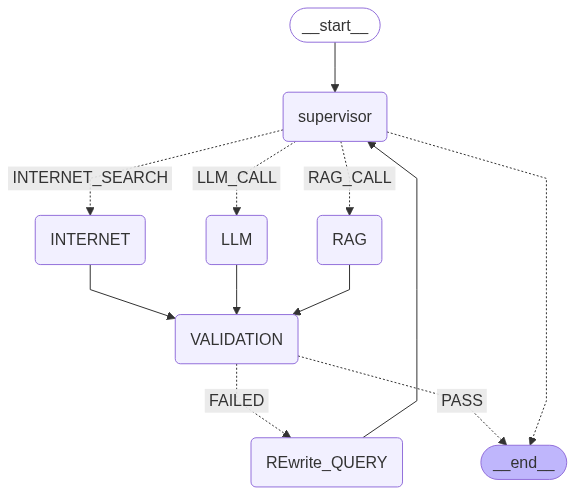

In [61]:
from langgraph.graph import START, StateGraph
from IPython.display import display, Image

workflow = StateGraph(State)

## Node
workflow.add_node("supervisor", supervisor)
workflow.add_node("LLM", llm_call)
workflow.add_node("RAG", rag_call)
workflow.add_node("INTERNET", internet_search)
workflow.add_node("VALIDATION", validation_node)
workflow.add_node("REwrite_QUERY", rewrite_query)

## Edges
workflow.add_edge(START, "supervisor")
workflow.add_conditional_edges(
    "supervisor",
    router,
    {
        "INTERNET_SEARCH": "INTERNET",
        "LLM_CALL": "LLM",
        "RAG_CALL": "RAG"
    }
)
workflow.add_edge("LLM", "VALIDATION")
workflow.add_edge("RAG", "VALIDATION")
workflow.add_edge("INTERNET", "VALIDATION")
workflow.add_conditional_edges(
    "VALIDATION",
    validation_router,
    {
        "PASS": END,
        "FAILED": "REwrite_QUERY"
    }
)
workflow.add_edge("REwrite_QUERY", "supervisor")

graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

#### Testing

In [62]:
graph.invoke(
    {
        "messages": ["What is key, query, and value vector?"]
    }
)

What is key, query, and value vector?
RAG_CALL The user query is directly related to the Transformer paper 'Attention Is All You Need'.
--Router--
RAG_CALL
--Rag call--
What is key, query, and value vector?
rag-response The query, key, and value vectors are vectors used in an attention function. The query vector is used to compute weights for the value vectors based on their similarity to the key vectors. Specifically, the query, key, and value vectors have dimensions that are used in the attention computation, denoted as dk for keys and queries, and dv for values.
---validation---
What is key, query, and value vector? The query, key, and value vectors are vectors used in an attention function. The query vector is used to compute weights for the value vectors based on their similarity to the key vectors. Specifically, the query, key, and value vectors have dimensions that are used in the attention computation, denoted as dk for keys and queries, and dv for values.
yes


{'messages': ['What is key, query, and value vector?',
  'RAG_CALL',
  'The query, key, and value vectors are vectors used in an attention function. The query vector is used to compute weights for the value vectors based on their similarity to the key vectors. Specifically, the query, key, and value vectors have dimensions that are used in the attention computation, denoted as dk for keys and queries, and dv for values.',
  'yes']}

In [64]:
graph.invoke(
    {
        "messages": ["What is the current weather of Hyderabad?"]
    }
)

What is the current weather of Hyderabad?
INTERNET_SEARCH The user is seeking current and specific information about the weather in Hyderabad, which requires an internet search for the most up-to-date information.
--Router--
INTERNET_SEARCH
--Internet Search--
---validation---
What is the current weather of Hyderabad? The current weather in Hyderabad is as follows:

- Temperature: 29.3°C (84.7°F)
- Condition: Mist
- Wind Speed: 29.5 km/h (18.3 mph) from the west-southwest (WSW)
- Pressure: 1007.0 mb (29.74 in)
- Humidity: 62%
- Cloud Cover: 50%
- Visibility: 5.0 km (3.0 miles)
- UV Index: 1.0

This information is based on the data available up to July 4, 2025, at 16:30 local time.

Source: https://www.weatherapi.com/ 

Please note that weather conditions are subject to change, and I recommend checking a reliable weather website or app for the most up-to-date information.
yes


{'messages': ['What is the current weather of Hyderabad?',
  'INTERNET_SEARCH',
  'The current weather in Hyderabad is as follows:\n\n- Temperature: 29.3°C (84.7°F)\n- Condition: Mist\n- Wind Speed: 29.5 km/h (18.3 mph) from the west-southwest (WSW)\n- Pressure: 1007.0 mb (29.74 in)\n- Humidity: 62%\n- Cloud Cover: 50%\n- Visibility: 5.0 km (3.0 miles)\n- UV Index: 1.0\n\nThis information is based on the data available up to July 4, 2025, at 16:30 local time.\n\nSource: https://www.weatherapi.com/ \n\nPlease note that weather conditions are subject to change, and I recommend checking a reliable weather website or app for the most up-to-date information.',
  'yes']}